In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. READ THE DATA

In [3]:
path = "../data/"
ufc = pd.read_csv(path+"UFC.csv")
fighters = pd.read_csv(path+"fighter_details.csv")
fight_stats = pd.read_csv(path+"fight_details.csv")


# 2. CHECK MAIN CARACTERISTICS OF TABLES

In [4]:
def table_audit(df, name):
    print(f"\n{'='*60}")
    print(f"TABLE : {name}")
    print(f"{'='*60}")
    print(f"Shape        : {df.shape}")
    print("\nTypes :")
    print(df.dtypes)
    print("\nValeurs manquantes (%) :")
    print((df.isna().mean() * 100).sort_values(ascending=False))
    print("\nDuplicats :", df.duplicated().sum())


table_audit(ufc, "UFC.csv")
table_audit(fighters, "fighter_details.csv")
table_audit(fight_stats, "fight_details.csv")



TABLE : UFC.csv
Shape        : (8337, 124)

Types :
event_id         object
event_name       object
date             object
location         object
fight_id         object
                 ...   
b_td_avg_acc      int64
b_td_def          int64
b_sub_avg       float64
winner           object
winner_id        object
Length: 124, dtype: object

Valeurs manquantes (%) :
b_ground_acc    45.771860
b_td_acc        37.495502
r_ground_acc    35.456399
r_td_acc        32.217824
b_nick_name     28.643397
                  ...    
r_td_avg         0.000000
r_td_avg_acc     0.000000
r_td_def         0.000000
r_sub_avg        0.000000
r_str_def        0.000000
Length: 124, dtype: float64

Duplicats : 0

TABLE : fighter_details.csv
Shape        : (2611, 19)

Types :
id             object
name           object
nick_name      object
wins            int64
losses          int64
draws           int64
height        float64
weight        float64
reach         float64
stance         object
dob            ob

In [5]:
ufc["date"] = pd.to_datetime(ufc["date"], errors="coerce")

print("Période couverte :")
print("Min :", ufc["date"].min())
print("Max :", ufc["date"].max())


Période couverte :
Min : 1994-03-11 00:00:00
Max : 2025-09-06 00:00:00


In [6]:
ufc["winner"].value_counts(normalize=True).sort_values(ascending=False)


winner
Jim Miller           0.003297
Charles Oliveira     0.002808
Donald Cerrone       0.002808
Max Holloway         0.002808
Neil Magny           0.002808
                       ...   
Chris Tuchscherer    0.000122
Yizha                0.000122
John Gunderson       0.000122
Mario Miranda        0.000122
Scott Morris         0.000122
Name: proportion, Length: 1828, dtype: float64

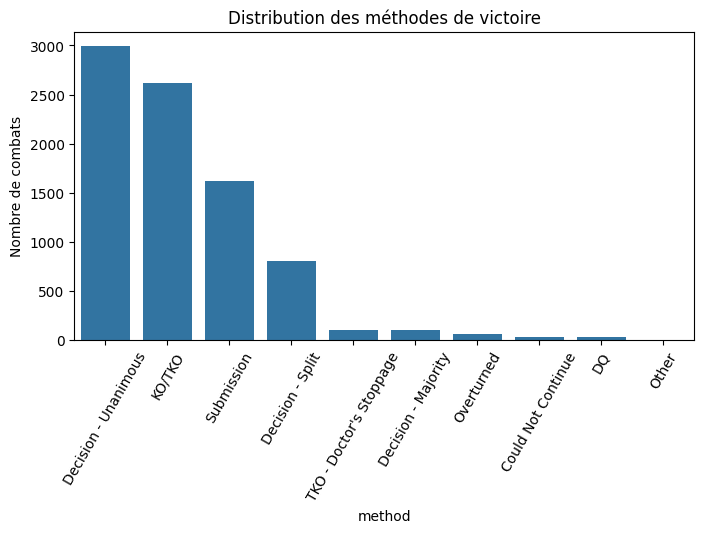

In [7]:
method_counts = ufc["method"].value_counts()

plt.figure(figsize=(8,4))
sns.barplot(x=method_counts.index, y=method_counts.values)
plt.title("Distribution des méthodes de victoire")
plt.ylabel("Nombre de combats")
plt.xticks(rotation=60)
plt.show()


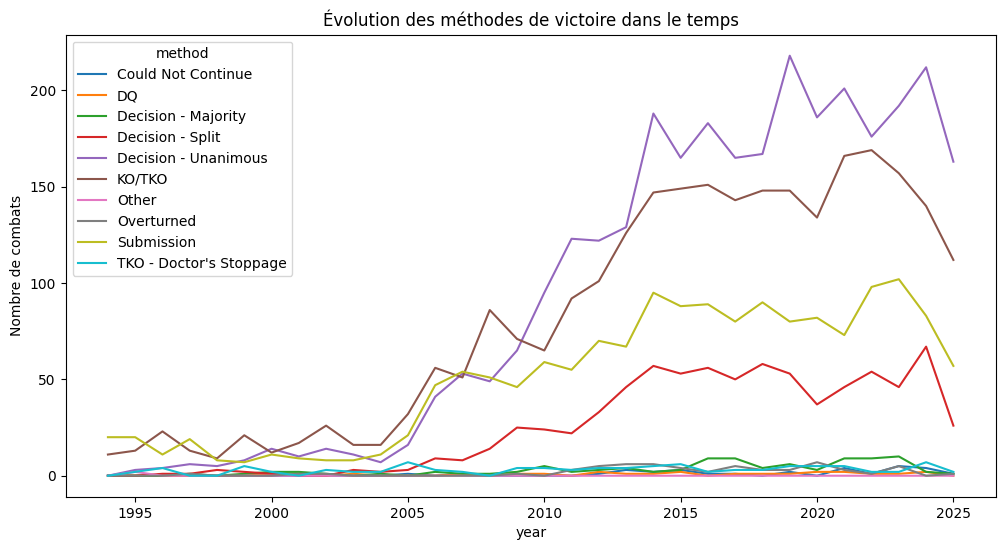

In [11]:
ufc["year"] = ufc["date"].dt.year

method_by_year = (
    ufc.groupby(["year", "method"])
       .size()
       .unstack(fill_value=0)
)

method_by_year.plot(figsize=(12,6))
plt.title("Évolution des méthodes de victoire dans le temps")
plt.ylabel("Nombre de combats")
plt.show()


In [12]:
ufc[ufc["method"].str.contains("No", case=False, na=False)]


,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,...,b_str_acc,b_sapm,b_str_def,b_td_avg,b_td_avg_acc,b_td_def,b_sub_avg,winner,winner_id,year
128,de277a4abcfeea46,UFC Fight Night: Usman vs. Buckley,2025-06-14,"Atlanta, Georgia, USA",13e2ff8b3a122094,light heavyweight,0,Could Not Continue,1,299,...,61,6.00,45,1.26,36,100,0.3,NaN,NaN,2025
611,66e0a70352fef46a,UFC Fight Night: Namajunas vs. Cortez,2024-07-13,"Denver, Colorado, USA",46fa8e79fe8a9539,middleweight,0,Could Not Continue,1,37,...,51,2.72,49,2.05,46,68,0.6,NaN,NaN,2024
769,c398235fcaf8d71d,UFC Fight Night: Tuivasa vs. Tybura,2024-03-16,"Las Vegas, Nevada, USA",a7fd9da657bbce8e,welterweight,0,Could Not Continue,2,60,...,46,6.59,52,2.53,39,83,0.2,NaN,NaN,2024
844,eaea0fc7b76525a8,UFC Fight Night: Hermansson vs. Pyfer,2024-02-10,"Las Vegas, Nevada, USA",6cd542650d886c22,bantamweight,0,Could Not Continue,2,208,...,49,5.46,48,1.20,46,58,0.0,NaN,NaN,2024
848,cce79e827569f26e,UFC Fight Night: Dolidze vs. Imavov,2024-02-03,"Las Vegas, Nevada, USA",415ea2520b7ba720,middleweight,0,Could Not Continue,1,11,...,43,2.57,61,3.03,66,77,0.2,NaN,NaN,2024
943,13a0fb8fbdafb54f,UFC 294: Makhachev vs. Volkanovski 2,2023-10-21,"Abu Dhabi, Abu Dhabi, United Arab Emirates",821960adf5bfa15c,light heavyweight,0,Could Not Continue,1,193,...,55,3.09,45,0.42,60,57,0.8,NaN,NaN,2023
948,13a0fb8fbdafb54f,UFC 294: Makhachev vs. Volkanovski 2,2023-10-21,"Abu Dhabi, Abu Dhabi, United Arab Emirates",0d1af8c6a5793185,bantamweight,0,Could Not Continue,2,15,...,53,5.19,48,1.04,42,81,0.3,NaN,NaN,2023
1147,a780d16cf7eed44d,UFC Fight Night: Emmett vs. Topuria,2023-06-24,"Jacksonville, Florida, USA",2874ea5d2f783e23,heavyweight,0,Could Not Continue,1,29,...,54,5.11,47,0.00,0,53,0.0,NaN,NaN,2023
1175,b6c6d1731ff00eeb,UFC 289: Nunes vs. Aldana,2023-06-10,"Vancouver, British Columbia, Canada",96eaf07b34538b8b,middleweight,0,Could Not Continue,2,184,...,50,6.19,54,0.00,0,82,0.0,NaN,NaN,2023
1242,6fb1ba67bef41b37,UFC Fight Night: Pavlovich vs. Blaydes,2023-04-22,"Las Vegas, Nevada, USA",640d52630f4f8a61,lightweight,0,Could Not Continue,1,275,...,55,3.91,56,1.83,32,62,0.0,NaN,NaN,2023


In [14]:
fighters.describe()


,wins,losses,draws,height,weight,reach,splm,str_acc,sapm,str_def,td_avg,td_avg_acc,td_def,sub_avg
count,2611.000000,2611.000000,2611.000000,2590.000000,2593.000000,1956.000000,2611.000000,2611.000000,2611.000000,2611.000000,2611.000000,2611.000000,2611.000000,2611.000000
mean,14.518192,6.171582,0.253543,178.300154,76.601836,182.026840,2.970689,40.911145,3.410896,48.951360,1.389288,32.093068,50.418614,0.582306
std,9.726172,4.531420,0.785441,8.963741,17.932949,10.757047,1.707846,14.796103,1.859872,15.799496,1.483164,25.257497,29.375228,1.063008
min,0.000000,0.000000,0.000000,152.400000,52.160000,147.320000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,3.000000,0.000000,172.720000,65.770000,175.260000,1.860000,36.000000,2.385000,45.000000,0.190000,10.000000,33.000000,0.000000
50%,13.000000,5.000000,0.000000,177.800000,70.310000,182.880000,2.930000,43.000000,3.260000,52.000000,1.000000,33.000000,56.000000,0.300000
75%,18.000000,8.000000,0.000000,185.420000,83.910000,190.500000,3.960000,50.000000,4.310000,58.000000,2.070000,47.000000,71.500000,0.800000
max,253.000000,53.000000,11.000000,210.820000,349.270000,213.360000,13.530000,100.000000,22.500000,100.000000,13.950000,100.000000,100.000000,21.900000


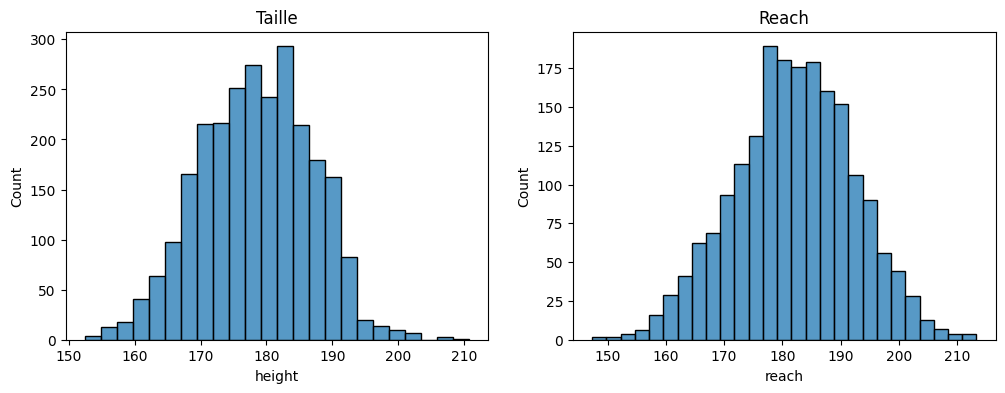

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(fighters["height"], bins=24, ax=ax[0])
ax[0].set_title("Taille")

sns.histplot(fighters["reach"], bins=27, ax=ax[1])
ax[1].set_title("Reach")

plt.show()


In [40]:
fighters["stance"].value_counts(normalize=True)


stance
Orthodox       0.765193
Southpaw       0.172060
Switch         0.059195
Open Stance    0.002368
Sideways       0.001184
Name: proportion, dtype: float64

In [42]:
fighters[["height", "reach", "stance"]].isna().mean() * 100


height     0.804290
reach     25.086174
stance     2.949062
dtype: float64

In [43]:
fight_stats["fight_id"].nunique(), len(fight_stats)


(8337, 8337)

In [44]:
(fight_stats.isna().mean() * 100).sort_values(ascending=False)


b_ground_acc    45.771860
b_td_acc        37.495502
r_ground_acc    35.456399
r_td_acc        32.217824
b_clinch_acc    24.493223
                  ...    
b_name           0.000000
r_id             0.000000
r_name           0.000000
fight_id         0.000000
event_name       0.000000
Length: 86, dtype: float64

In [47]:
print(ufc.columns.tolist())
print(fighters.columns.tolist())


['event_id', 'event_name', 'date', 'location', 'fight_id', 'division', 'title_fight', 'method', 'finish_round', 'match_time_sec', 'total_rounds', 'referee', 'r_name', 'r_id', 'r_kd', 'r_sig_str_landed', 'r_sig_str_atmpted', 'r_sig_str_acc', 'r_total_str_landed', 'r_total_str_atmpted', 'r_total_str_acc', 'r_td_landed', 'r_td_atmpted', 'r_td_acc', 'r_sub_att', 'r_ctrl', 'r_head_landed', 'r_head_atmpted', 'r_head_acc', 'r_body_landed', 'r_body_atmpted', 'r_body_acc', 'r_leg_landed', 'r_leg_atmpted', 'r_leg_acc', 'r_dist_landed', 'r_dist_atmpted', 'r_dist_acc', 'r_clinch_landed', 'r_clinch_atmpted', 'r_clinch_acc', 'r_ground_landed', 'r_ground_atmpted', 'r_ground_acc', 'r_landed_head_per', 'r_landed_body_per', 'r_landed_leg_per', 'r_landed_dist_per', 'r_landed_clinch_per', 'r_landed_ground_per', 'r_nick_name', 'r_wins', 'r_losses', 'r_draws', 'r_height', 'r_weight', 'r_reach', 'r_stance', 'r_dob', 'r_splm', 'r_str_acc', 'r_sapm', 'r_str_def', 'r_td_avg', 'r_td_avg_acc', 'r_td_def', 'r_sub_

In [48]:
import numpy as np

df = ufc.copy()

df["winner_reach"] = np.where(
    df["winner"] == df["r_name"],
    df["r_reach"],
    df["b_reach"]
)

df["loser_reach"] = np.where(
    df["winner"] == df["r_name"],
    df["b_reach"],
    df["r_reach"]
)

df[["winner_reach", "loser_reach"]].mean()


winner_reach    183.198175
loser_reach     182.578129
dtype: float64

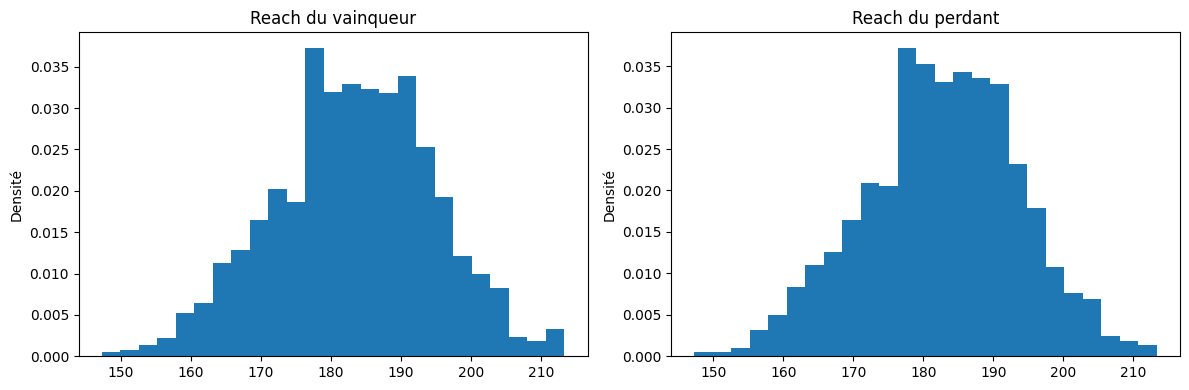

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["winner_reach"].dropna(), bins=25, density=True)
ax[0].set_title("Reach du vainqueur")
ax[0].set_ylabel("Densité")

ax[1].hist(df["loser_reach"].dropna(), bins=25, density=True)
ax[1].set_title("Reach du perdant")
ax[1].set_ylabel("Densité")

plt.tight_layout()
plt.show()


In [52]:
df["date"] = pd.to_datetime(df["date"])
df["r_dob"] = pd.to_datetime(df["r_dob"], errors="coerce")
df["b_dob"] = pd.to_datetime(df["b_dob"], errors="coerce")

df["winner_age"] = np.where(
    df["winner"] == df["r_name"],
    (df["date"] - df["r_dob"]).dt.days / 365.25,
    (df["date"] - df["b_dob"]).dt.days / 365.25
)

df["winner_age"].describe()


count    8267.000000
mean       29.966728
std         4.007490
min        18.171116
25%        27.141684
50%        29.776865
75%        32.550308
max        47.184120
Name: winner_age, dtype: float64